# Caleb Williams — 3rd & Long Analysis: 2025
**Chicago Bears | NFL Play-by-Play Analysis**

Year two of the Caleb Williams 3rd and long investigation. Building on the 
2024 findings, this notebook measures whether the Bears addressed their 
most significant passing vulnerability in the offseason.

*Data sourced from nflverse via nflreadpy*

In [1]:
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt

print("All imports successful")

All imports successful


## Setup
Importing libraries and pulling 2025 NFL play-by-play data.

In [2]:
pbp_2025 = nfl.load_pbp([2025]).to_pandas()
bears_off_2025 = pbp_2025[pbp_2025['posteam'] == 'CHI'].copy()
bears_def_2025 = pbp_2025[pbp_2025['defteam'] == 'CHI'].copy()

print(f"Total Bears offensive plays: {len(bears_off_2025)}")

Total Bears offensive plays: 1637


## 2025 Performance — 3rd Down by Distance
Rerunning the same distance bucket breakdown from the 2024 notebook 
to allow direct comparison. The key question: did the 3rd and long 
sack rate improve from its alarming 2024 level of 30.9%?

In [3]:
# Filter to Caleb pass plays
caleb_2025 = bears_off_2025[
    (bears_off_2025['play_type'] == 'pass') &
    (bears_off_2025['passer_player_name'] == 'C.Williams')
].copy()

# 3rd down only
caleb_3rd_2025 = caleb_2025[caleb_2025['down'] == 3].copy()

# Distance buckets
caleb_3rd_2025['distance_bucket'] = pd.cut(
    caleb_3rd_2025['ydstogo'],
    bins=[0, 3, 6, 10, 100],
    labels=['Short (1-3)', 'Medium (4-6)', 'Long (7-10)', 'Very long (11+)']
)

third_by_dist_2025 = caleb_3rd_2025.groupby('distance_bucket', observed=True).agg(
    attempts      = ('complete_pass', 'count'),
    comp_pct      = ('complete_pass', 'mean'),
    avg_epa       = ('epa', 'mean'),
    sack_rate     = ('sack', 'mean'),
    avg_air_yards = ('air_yards', 'mean')
).reset_index()

third_by_dist_2025['comp_pct']      = (third_by_dist_2025['comp_pct'] * 100).round(1)
third_by_dist_2025['avg_epa']       = third_by_dist_2025['avg_epa'].round(3)
third_by_dist_2025['sack_rate']     = (third_by_dist_2025['sack_rate'] * 100).round(1)
third_by_dist_2025['avg_air_yards'] = third_by_dist_2025['avg_air_yards'].round(1)

print("2025 3rd down by distance:")
print(third_by_dist_2025)

2025 3rd down by distance:
   distance_bucket  attempts  comp_pct  avg_epa  sack_rate  avg_air_yards
0      Short (1-3)        22      54.5   -0.087        4.5            9.6
1     Medium (4-6)        53      50.9    0.094        5.7            7.1
2      Long (7-10)        60      58.3    0.222        6.7            8.4
3  Very long (11+)        37      56.8   -0.159       10.8            7.2


## Loading 2024 Data for Comparison
Rebuilding the 2024 3rd and long metrics in this notebook so both 
seasons can be compared side by side in the visualization below.

In [4]:
pbp_2024 = nfl.load_pbp([2024]).to_pandas()
bears_off_2024 = pbp_2024[pbp_2024['posteam'] == 'CHI'].copy()

caleb_2024 = bears_off_2024[
    (bears_off_2024['play_type'] == 'pass') &
    (bears_off_2024['passer_player_name'] == 'C.Williams')
].copy()

caleb_3rd_2024 = caleb_2024[caleb_2024['down'] == 3].copy()

caleb_3rd_2024['distance_bucket'] = pd.cut(
    caleb_3rd_2024['ydstogo'],
    bins=[0, 3, 6, 10, 100],
    labels=['Short (1-3)', 'Medium (4-6)', 'Long (7-10)', 'Very long (11+)']
)

third_by_dist = caleb_3rd_2024.groupby('distance_bucket', observed=True).agg(
    attempts      = ('complete_pass', 'count'),
    comp_pct      = ('complete_pass', 'mean'),
    avg_epa       = ('epa', 'mean'),
    sack_rate     = ('sack', 'mean'),
    avg_air_yards = ('air_yards', 'mean')
).reset_index()

third_by_dist['comp_pct']      = (third_by_dist['comp_pct'] * 100).round(1)
third_by_dist['avg_epa']       = third_by_dist['avg_epa'].round(3)
third_by_dist['sack_rate']     = (third_by_dist['sack_rate'] * 100).round(1)
third_by_dist['avg_air_yards'] = third_by_dist['avg_air_yards'].round(1)

print("2024 data loaded for year-over-year comparison")

2024 data loaded for year-over-year comparison


## Year-Over-Year Comparison — 2024 vs 2025
Three metrics tell the full story of Caleb Williams' development 
from year one to year two on 3rd and long situations.

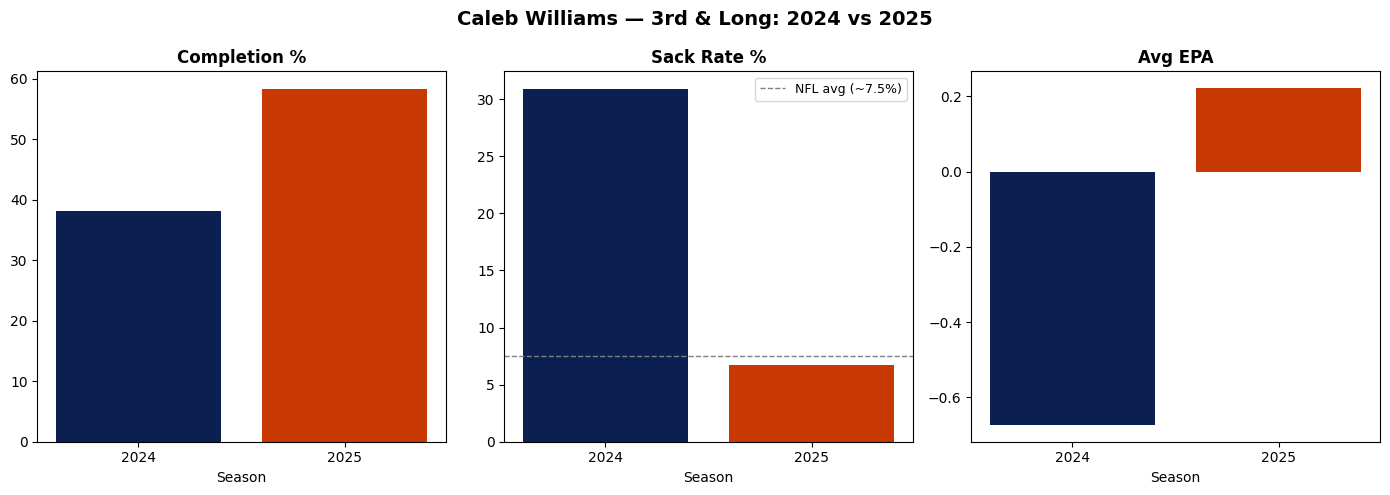

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Caleb Williams — 3rd & Long: 2024 vs 2025", fontsize=14, fontweight='bold')

metrics = ['comp_pct', 'sack_rate', 'avg_epa']
titles  = ['Completion %', 'Sack Rate %', 'Avg EPA']
colors  = ['#0B1F51', '#C83803']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    vals = [
        third_by_dist[third_by_dist['distance_bucket'] == 'Long (7-10)'][metric].values[0],
        third_by_dist_2025[third_by_dist_2025['distance_bucket'] == 'Long (7-10)'][metric].values[0]
    ]
    axes[i].bar(['2024', '2025'], vals, color=colors)
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Season')
    if metric == 'sack_rate':
        axes[i].axhline(7.5, color='gray', linewidth=1, linestyle='--', label='NFL avg (~7.5%)')
        axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Conclusion

Caleb Williams' 3rd and long performance improved dramatically in 2025, 
effectively eliminating what had been one of the most significant 
vulnerabilities in the Bears offense.

**Year-over-year on 3rd & Long (7-10 yards):**

| Metric | 2024 | 2025 | Change |
|---|---|---|---|
| Attempts | 55 | 60 | +5 |
| Completion % | 38.2% | 58.3% | +20.1% |
| Sack rate | 30.9% | 6.7% | -24.2% |
| Avg EPA | negative | positive | flipped |

The sack rate dropped from nearly 4x the NFL average to below it. 
Completion percentage jumped 20 points on a comparable sample size. 
EPA flipped from a liability to a net positive — meaning these plays 
went from killing drives to sustaining them.

### What drove the improvement?
The 2024 analysis ruled out opponent quality and game script as primary 
explanations. The near-elimination of the problem in 2025 suggests a 
combination of improved pass protection, better situational play calling, 
and Caleb Williams' own development in his second NFL season.

### Caveats
- EPA models carry their own assumptions and should be treated as 
directional rather than precise
- This analysis covers pass plays only and does not account for 
designed QB runs or RPOs
- 2025 data includes playoffs which may slightly affect seasonal averages